In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "WasteBySectionOfEconomicActivitys";',
    engine
)
df

,Id,Year,Type,Total,Agriculture,Mining,Manufacturing,Energy,WaterWaste,Construction,...,RealEstate,Professional,Administrative,PublicAdmin,Education,Healthcare,Arts,OtherServices,Households,Extraterritorial
0,1,2018,Generated waste,1142663.0,2409.0,161619.0,531762.0,5449.0,270379.0,35617.0,...,221.0,548.0,91325.0,457.0,1753.0,4639.0,135.0,79.0,0.0,0.0
1,2,2018,Non-hazardous waste,1122179.0,2396.0,154591.0,527278.0,5149.0,268589.0,35049.0,...,221.0,548.0,91325.0,457.0,1753.0,4151.0,135.0,55.0,0.0,0.0
2,3,2018,Hazardous waste,20484.0,14.0,7028.0,4483.0,300.0,1790.0,568.0,...,NaN,NaN,NaN,NaN,NaN,488.0,NaN,24.0,NaN,NaN
3,4,2020,Generated waste,1488218.0,126.0,521259.0,519617.0,7997.0,266240.0,56217.0,...,NaN,106.0,721.0,177.0,2562.0,7612.0,281.0,70.0,NaN,NaN
4,5,2020,Non-hazardous waste,1070042.0,126.0,109085.0,517391.0,7404.0,264831.0,56103.0,...,NaN,100.0,721.0,177.0,2562.0,6580.0,281.0,70.0,NaN,NaN
5,6,2020,Hazardous waste,418177.0,NaN,412174.0,2227.0,593.0,1409.0,114.0,...,NaN,6.0,NaN,NaN,NaN,1032.0,NaN,NaN,NaN,NaN
6,7,2022,Generated waste,1396959.0,462.0,496978.0,491332.0,10282.0,218316.0,64463.0,...,NaN,417.0,536.0,353.0,1882.0,6594.0,1475.0,25.0,NaN,NaN
7,8,2022,Non-hazardous waste,985406.0,462.0,91989.0,488836.0,9668.0,217108.0,64087.0,...,NaN,417.0,536.0,353.0,1879.0,5768.0,1475.0,25.0,NaN,NaN
8,9,2022,Hazardous waste,411553.0,NaN,404989.0,2496.0,614.0,1208.0,375.0,...,NaN,NaN,NaN,NaN,3.0,826.0,NaN,NaN,NaN,NaN


In [18]:
df = df.drop(columns=["Id", "Households", "Extraterritorial"])
columns_to_model = df.columns.drop(["Year", "Type"])
df[columns_to_model] = df[columns_to_model].fillna(df[columns_to_model].mean())
future_years = pd.DataFrame({"Year": [2023, 2024, 2025, 2026, 2027, 2028]})

In [19]:
import os

os.makedirs("../models/WasteBySectionOfEconomicActivitys", exist_ok=True)

In [20]:
from sklearn.linear_model import LinearRegression
import joblib

forecasts = {}

for waste_type in df["Type"].unique():
    df_type = df[df["Type"] == waste_type].reset_index(drop=True)
    forecasts[waste_type] = {}

    for col in columns_to_model:
        X = df_type[["Year"]].values
        y = df_type[col].values

        lr = LinearRegression()
        lr.fit(X, y)

        pred = lr.predict(future_years[["Year"]].values)
        forecasts[waste_type][col] = pred

        joblib.dump(lr, f"../models/WasteBySectionOfEconomicActivitys/{waste_type}_{col}_lr_model.pkl")

forecast_dfs = {}
for waste_type, data in forecasts.items():
    forecast_dfs[waste_type] = pd.DataFrame(data, index=future_years["Year"])

print("Forecasts for Generated waste:")
print(forecast_dfs["Generated waste"])

combined_forecast = pd.concat(forecast_dfs, axis=1)
print("\nCombined forecast:")
print(combined_forecast)

Forecasts for Generated waste:
             Total  Agriculture        Mining  Manufacturing        Energy  \
Year                                                                         
2023  1.533335e+06      -461.25  6.448046e+05       483914.5  11534.083333   
2024  1.596909e+06      -948.00  7.286443e+05       473807.0  12742.333333   
2025  1.660483e+06     -1434.75  8.124841e+05       463699.5  13950.583333   
2026  1.724057e+06     -1921.50  8.963238e+05       453592.0  15158.833333   
2027  1.787631e+06     -2408.25  9.801636e+05       443484.5  16367.083333   
2028  1.851205e+06     -2895.00  1.064003e+06       433377.0  17575.333333   

      WaterWaste  Construction          Trade  Transportation  Hospitality  \
Year                                                                         
2023   212597.75       73733.5  125182.416667      887.416667  5248.666667   
2024   199582.00       80945.0  143111.666667     -644.333333  5764.666667   
2025   186566.25       88156.5  

/var/folders/1r/8qsv6l4d2xs9tv69xpg5sfqw0000gn/T/ipykernel_15569/4109540199.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


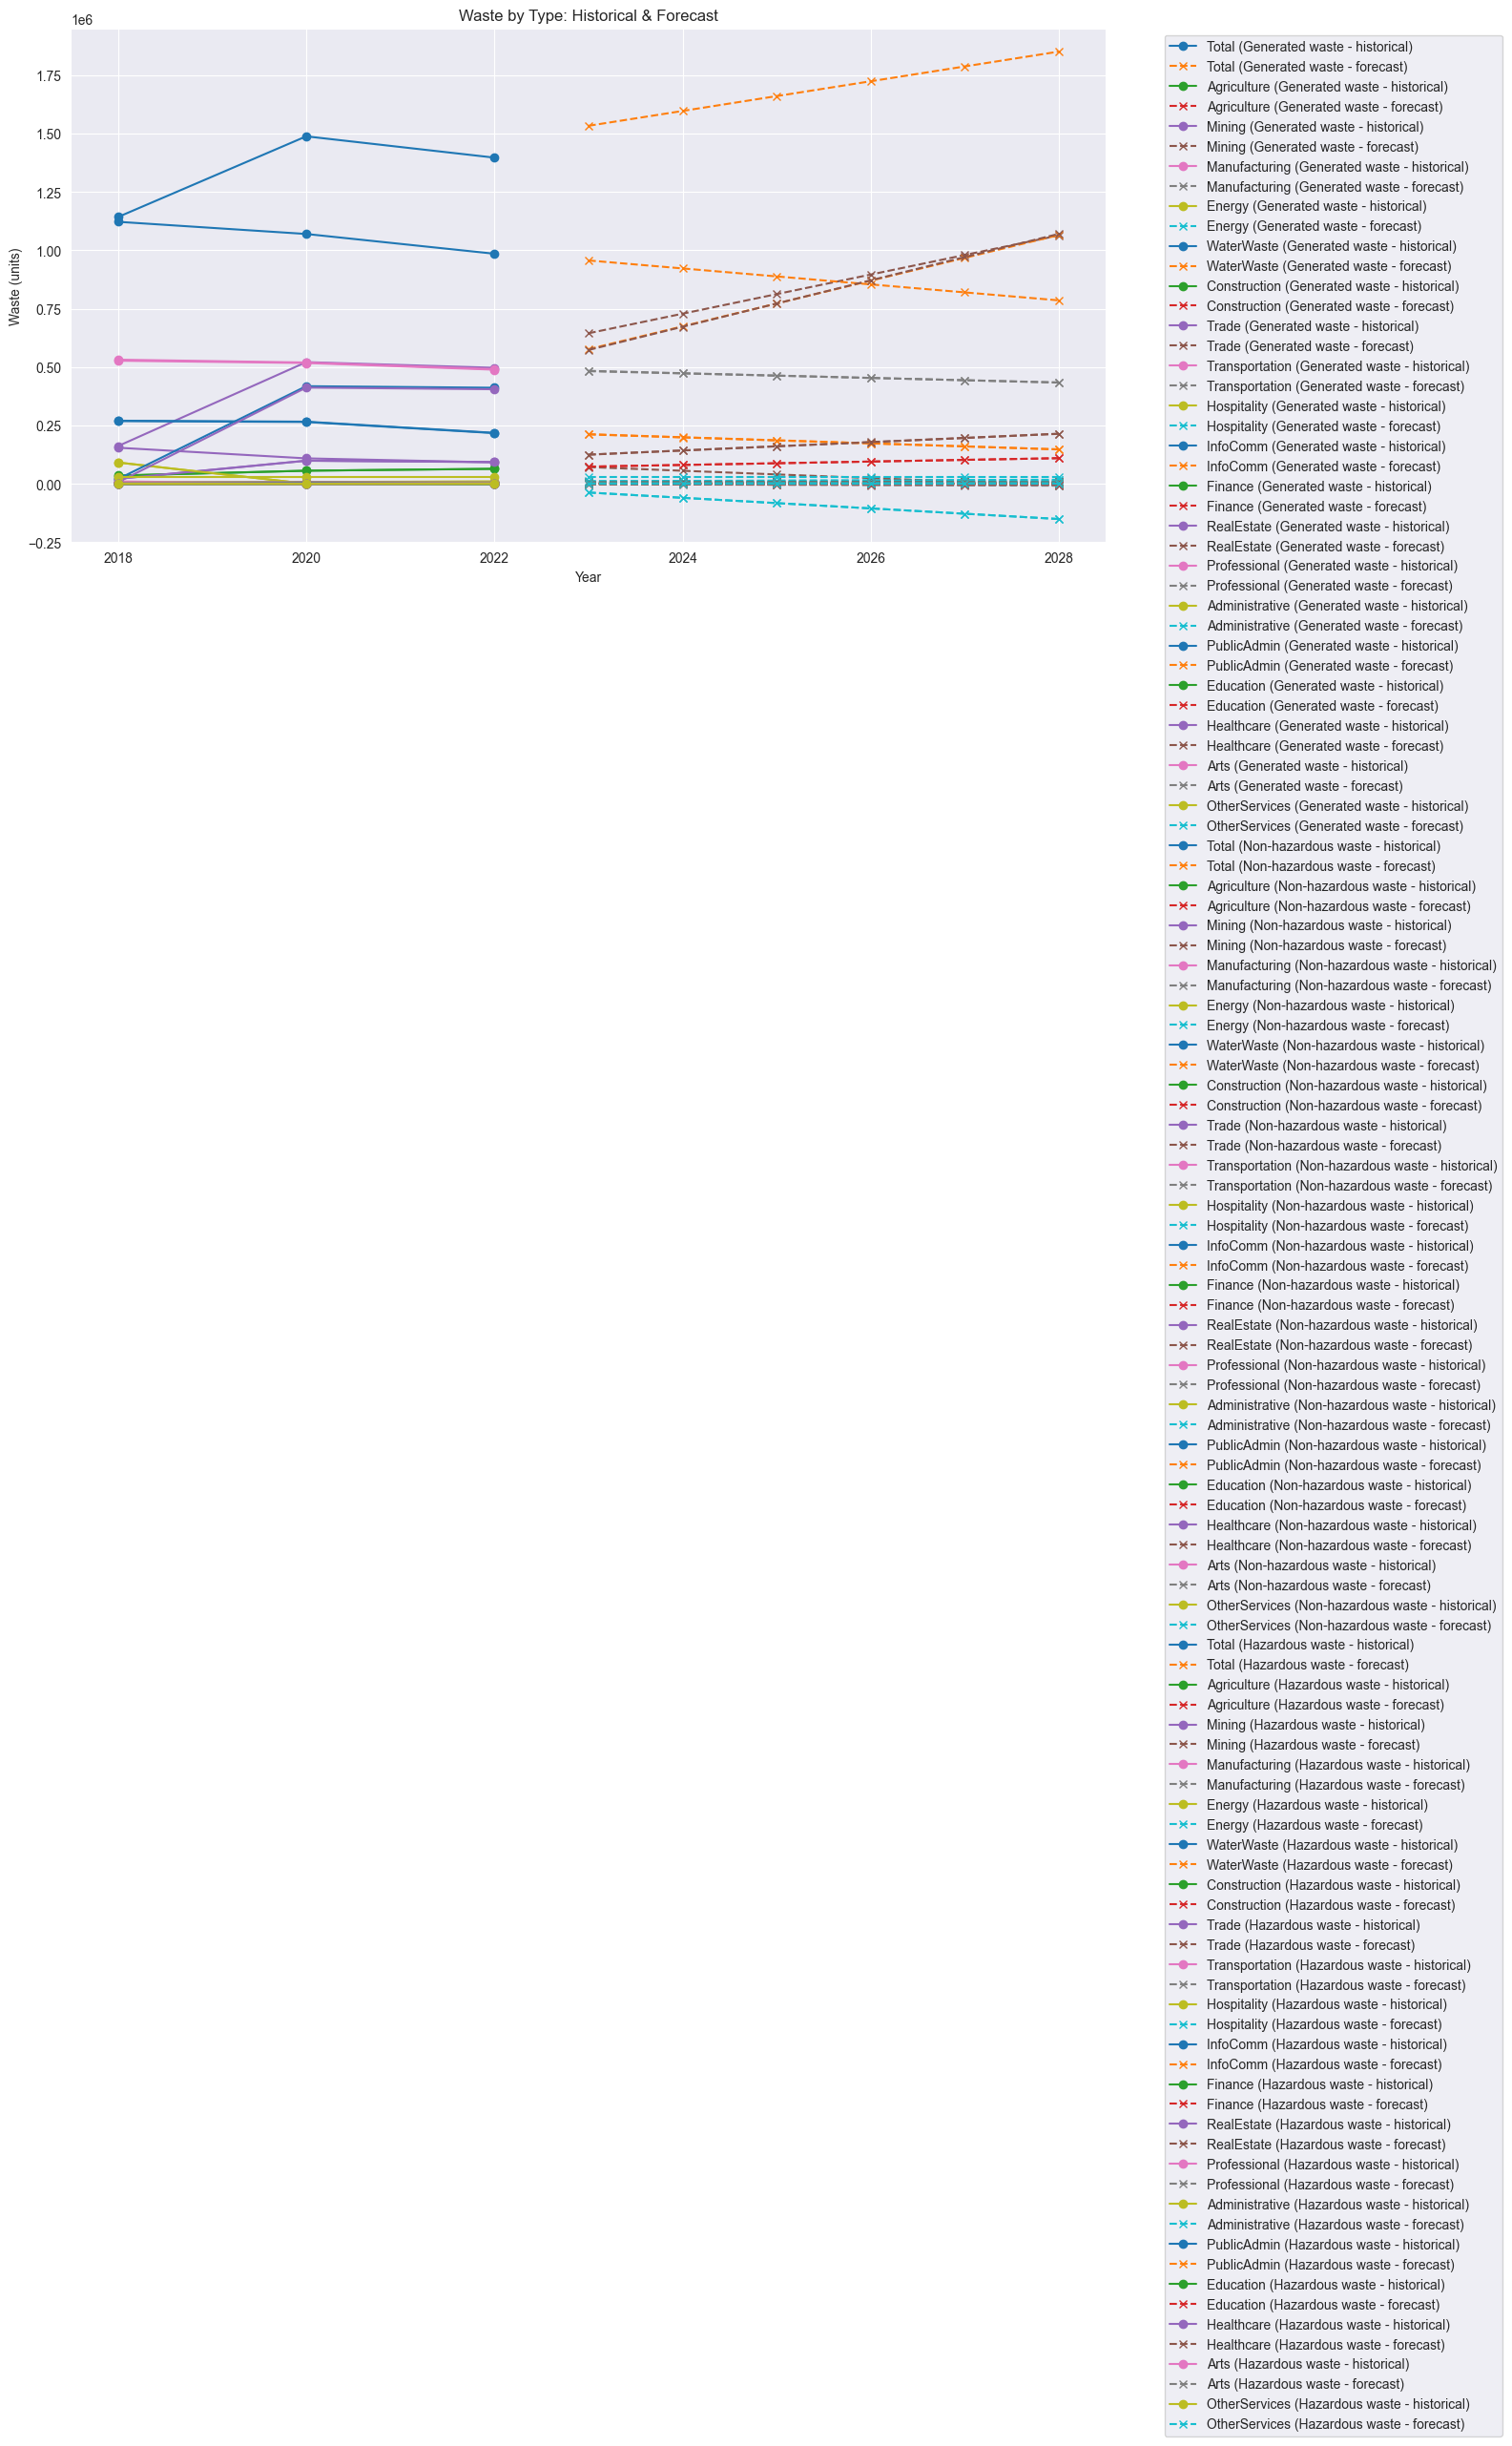

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))
for waste_type in df["Type"].unique():
    df_type = df[df["Type"] == waste_type]
    for col in columns_to_model:
        plt.plot(df_type["Year"], df_type[col], marker='o', label=f"{col} ({waste_type} - historical)")
        plt.plot(future_years["Year"], forecast_dfs[waste_type][col], marker='x', linestyle='--', label=f"{col} ({waste_type} - forecast)")

plt.title("Waste by Type: Historical & Forecast")
plt.xlabel("Year")
plt.ylabel("Waste (units)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()